### Notebook for exploration of the dataset locally generated

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path

sys.path.insert(0, str(Path("..").resolve()))
from src.features import add_time_features

Download the new parquet generated from queries_pvdaq.py

In [2]:
df = pd.read_parquet("../data/pvdaq_system10_2019_2023.parquet")

Check dataset for missing values and statistical description

In [3]:
print(df.isna().sum())
print(df.describe())

timestamp               0
irradiance          87442
dc_power             3839
ac_power             4537
ambient_temp         4986
module_temp_mean    10021
dtype: int64
                        timestamp    irradiance      dc_power      ac_power  \
count                     1990900  1.903458e+06  1.987061e+06  1.986363e+06   
mean   2021-03-22 14:03:10.291617  2.424826e+02  2.241957e+02  1.819323e+02   
min           2019-01-03 07:52:00  0.000000e+00  0.000000e+00  0.000000e+00   
25%           2020-04-18 06:04:45  0.000000e+00  0.000000e+00  0.000000e+00   
50%           2021-04-02 20:01:30  2.601300e+00  6.043000e-02  0.000000e+00   
75%           2022-03-15 13:36:15  3.909375e+02  3.592300e+02  2.914600e+02   
max           2023-03-01 06:59:00  4.938000e+03  1.638500e+03  1.339500e+03   
std                           NaN  3.813654e+02  3.507303e+02  2.873634e+02   

       ambient_temp  module_temp_mean  
count  1.985914e+06      1.980879e+06  
mean   1.194464e+01      1.767829e+01  

In [4]:
monthly = (
    df.set_index("timestamp")["irradiance"]
    .resample("ME")
    .agg(["count", "size"])
)

monthly["missing_pct"] = (
    1 - monthly["count"] / monthly["size"]
) * 100

monthly[["missing_pct"]]

,missing_pct
timestamp,
2019-01-31,76.742627
2019-02-28,59.488491
2019-03-31,4.819866
2019-04-30,0.000000
2019-05-31,0.000000
2019-06-30,0.000000
2019-07-31,0.000000
2019-08-31,0.000000
2019-09-30,0.000000


is NaN values or non-registered data? 

In [5]:
missing_irradiance = df[df["irradiance"].isna()]

print(missing_irradiance["timestamp"].min())
print(missing_irradiance["timestamp"].max())

2019-01-03 07:52:00
2022-07-25 15:22:00


In [6]:
missing_by_month = (
    missing_irradiance
    .set_index("timestamp")
    .resample("ME")
    .size()
)

print(missing_by_month)

timestamp
2019-01-31     1145
2019-02-28     1163
2019-03-31      887
2019-04-30        0
2019-05-31        0
2019-06-30        0
2019-07-31        0
2019-08-31        0
2019-09-30        0
2019-10-31        0
2019-11-30        0
2019-12-31        0
2020-01-31        0
2020-02-29        0
2020-03-31        0
2020-04-30        0
2020-05-31        0
2020-06-30        0
2020-07-31        0
2020-08-31        0
2020-09-30        0
2020-10-31        0
2020-11-30        0
2020-12-31        0
2021-01-31        0
2021-02-28        5
2021-03-31        0
2021-04-30        0
2021-05-31        0
2021-06-30        0
2021-07-31        0
2021-08-31        0
2021-09-30        0
2021-10-31        0
2021-11-30        0
2021-12-31        0
2022-01-31        0
2022-02-28        0
2022-03-31        0
2022-04-30        2
2022-05-31    13771
2022-06-30    41702
2022-07-31    28767
Freq: ME, dtype: int64


the 2022 period of missing values looks like there was a problem with the sensor of irradiance, let's check it and also for 2019, just in case

In [7]:
bad_period_2022 = df[
    df["timestamp"].between("2022-05-01", "2022-07-25")
]

print(bad_period_2022.isna().sum())

timestamp               0
irradiance          84233
dc_power                0
ac_power                0
ambient_temp            0
module_temp_mean        0
dtype: int64


In [8]:
bad_period_2019 = df[
    df["timestamp"].between("2019-01-03", "2019-03-31")
]

print(bad_period_2019.isna().sum())

timestamp              0
irradiance          3195
dc_power            3832
ac_power            4529
ambient_temp        4975
module_temp_mean    4896
dtype: int64


once we are sure about the periods of missing values, we are going to drop them, because irradiance will be a very important feature and this will confuse our model

In [9]:
# Eliminar periodo defectuoso de 2019
df = df[
    ~df["timestamp"].between("2019-01-03", "2019-03-31")
]

# Eliminar periodo defectuoso de 2022
df = df[
    ~df["timestamp"].between("2022-05-01", "2022-07-25")
]

we saw anomalies for irradiance, let's check it with a boxplot to see outliers

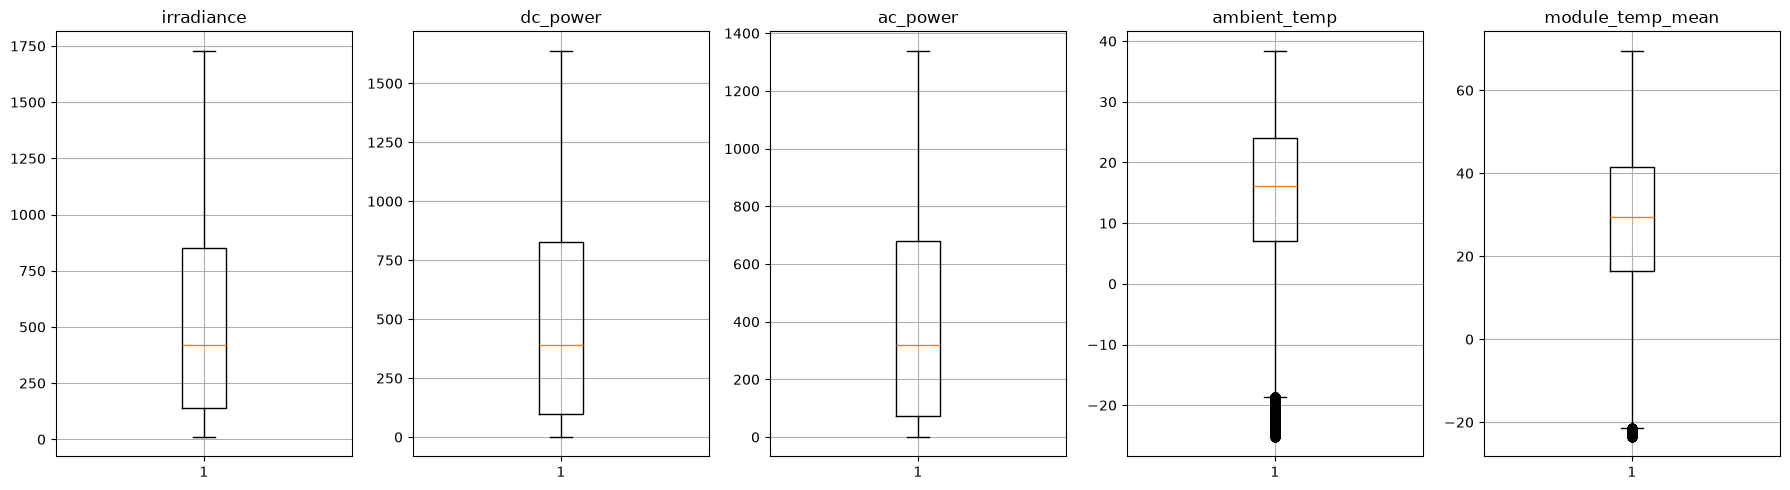

,timestamp,irradiance,dc_power,ac_power,ambient_temp,module_temp_mean
count,888265,888265.000000,888262.000000,888261.000000,888263.000000,886364.000000
mean,2021-02-06 13:20:01.990081,493.809728,466.965484,379.701002,15.120455,28.738084
min,2019-03-31 00:01:00,10.001000,0.000000,0.000000,-25.251000,-23.580333
25%,2020-03-22 17:18:00,137.960000,96.713000,72.340000,6.992300,16.373583
50%,2021-02-10 20:56:00,417.420000,390.930000,318.740000,16.147000,29.541333
75%,2021-12-17 22:55:00,850.620000,828.600000,680.080000,24.057500,41.536083
max,2023-03-01 00:30:00,1729.200000,1638.500000,1339.500000,38.430000,69.542000
std,NaN,376.950502,381.645179,314.832224,11.113010,16.932310


In [10]:
df_plot = df[df["irradiance"] > 10]

fig, axes = plt.subplots(1, 5, figsize=(18, 5))

variables = [
    "irradiance",
    "dc_power",
    "ac_power",
    "ambient_temp",
    "module_temp_mean"
]

for ax, variable in zip(axes, variables):
    ax.boxplot(df_plot[variable].dropna())
    ax.set_title(variable)
    ax.grid(True)

plt.tight_layout()
plt.show()
df_plot.describe()

df.loc[df["irradiance"] > 1500, ["timestamp", "irradiance"]].head()
df.loc[df["irradiance"] > 1500, "timestamp"].agg(["min", "max"])

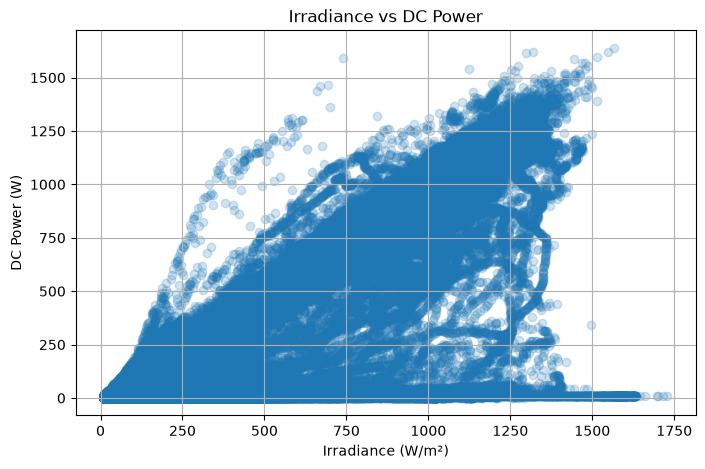

In [11]:
plt.figure(figsize=(8, 5))
plt.scatter(
    df_plot["irradiance"],
    df_plot["dc_power"],
    alpha=0.2
)

plt.xlabel("Irradiance (W/m²)")
plt.ylabel("DC Power (W)")
plt.title("Irradiance vs DC Power")
plt.grid(True)
plt.show()

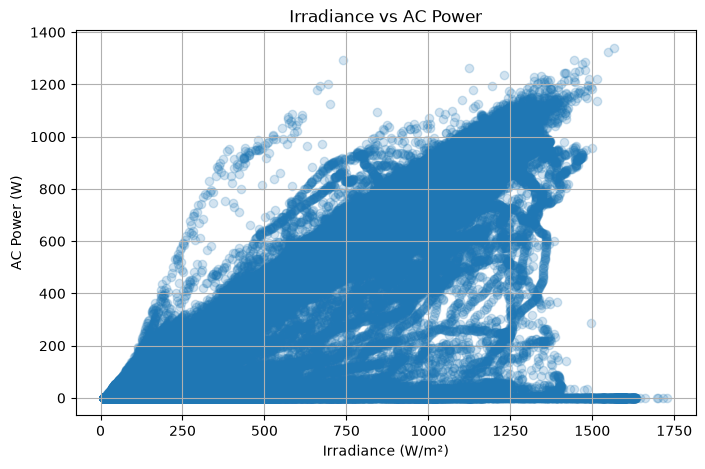

In [12]:
plt.figure(figsize=(8, 5))
plt.scatter(
    df_plot["irradiance"],
    df_plot["ac_power"],
    alpha=0.2
)

plt.xlabel("Irradiance (W/m²)")
plt.ylabel("AC Power (W)")
plt.title("Irradiance vs AC Power")
plt.grid(True)
plt.show()

the ratio between dc/ac power should be always dc>ac, let's check if this is true and if not let's see if is only noise or maybe invalid data

In [13]:
print(df.loc[
    df["dc_power"] < df["ac_power"],
    ["timestamp", "irradiance", "dc_power", "ac_power", "ambient_temp", "module_temp_mean"]
].head(20))

                 timestamp  irradiance  dc_power  ac_power  ambient_temp  \
99361  2019-05-24 20:01:00    1052.900    0.0000   0.01107      21.37600   
368336 2019-11-27 14:56:00     327.890   15.9130  19.57000     -10.90300   
368826 2019-11-27 23:06:00      45.398    3.0977   3.46050      -9.47490   
368827 2019-11-27 23:07:00      43.628    1.6918   2.19610      -9.52350   
368828 2019-11-27 23:08:00      40.974    1.3531   1.86330      -9.54480   
369735 2019-11-28 14:15:00      74.871    7.7507   8.14740     -10.58000   
371222 2019-11-29 15:02:00      59.088    9.1312   9.72200      -9.40060   
371256 2019-11-29 15:36:00      95.328   19.5280  19.67700      -8.21290   
399467 2020-02-03 18:47:00      76.463    3.7694   3.99400      -7.82290   
399499 2020-02-03 19:19:00     121.130    5.0162   5.18110      -7.65170   
420850 2020-02-18 15:10:00     210.300   10.9850  12.39700      -6.44460   
431480 2020-02-26 00:20:00      30.525    2.5054   2.60710      -5.87760   
464181 2020-

let's study the data whit high irradiance and low power production

In [14]:
low_power_high_irr = df[
    (df["irradiance"] > 500) &
    (df["ac_power"] < 50)
]

print(len(low_power_high_irr))

5724


In [15]:
low_power_high_irr['year_month'] = (
    low_power_high_irr['timestamp']
    .dt.to_period('M')
)

print(
    low_power_high_irr['year_month']
    .value_counts()
    .sort_index()
)

year_month
2019-05      13
2019-06       1
2019-07      29
2019-10     317
2019-11       9
2020-02     466
2020-04      70
2020-06      11
2020-10     306
2020-11      13
2020-12      27
2021-01      43
2021-02     166
2021-04      31
2021-05      27
2021-06     291
2021-07      12
2021-09      17
2021-10       5
2021-12      39
2022-01     112
2022-02     606
2022-03     130
2022-04      19
2022-08       6
2022-09     295
2022-10       1
2022-11    1695
2022-12     416
2023-01      48
2023-02     503
Freq: M, Name: count, dtype: int64


let's check periods with big amount of days of high irradiance and low power

In [16]:
nov_2022 = low_power_high_irr[
    low_power_high_irr["year_month"] == "2022-11"
]

print(nov_2022["timestamp"].min())
print(nov_2022["timestamp"].max())

2022-11-04 14:40:00
2022-11-29 18:49:00


In [17]:
nov_2022['timestamp'].dt.date.value_counts().sort_index()

timestamp
2022-11-04     31
2022-11-15     27
2022-11-18     37
2022-11-24    118
2022-11-25    491
2022-11-26    471
2022-11-27    430
2022-11-28     77
2022-11-29     13
Name: count, dtype: int64

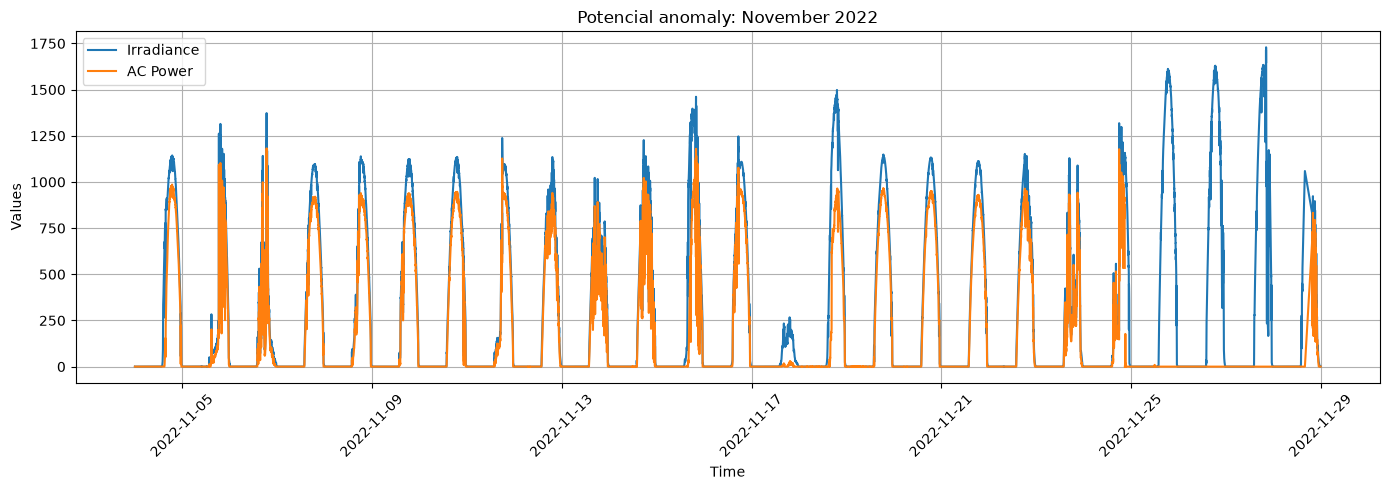

In [18]:
nov_problem = df[
    df['timestamp'].between(
        '2022-11-04',
        '2022-11-29'
    )
]

plt.figure(figsize=(14, 5))
plt.plot(nov_problem['timestamp'], nov_problem['irradiance'], label='Irradiance')
plt.plot(nov_problem['timestamp'], nov_problem['ac_power'], label='AC Power')
plt.xlabel('Time')
plt.ylabel('Values')
plt.title('Potencial anomaly: November 2022')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

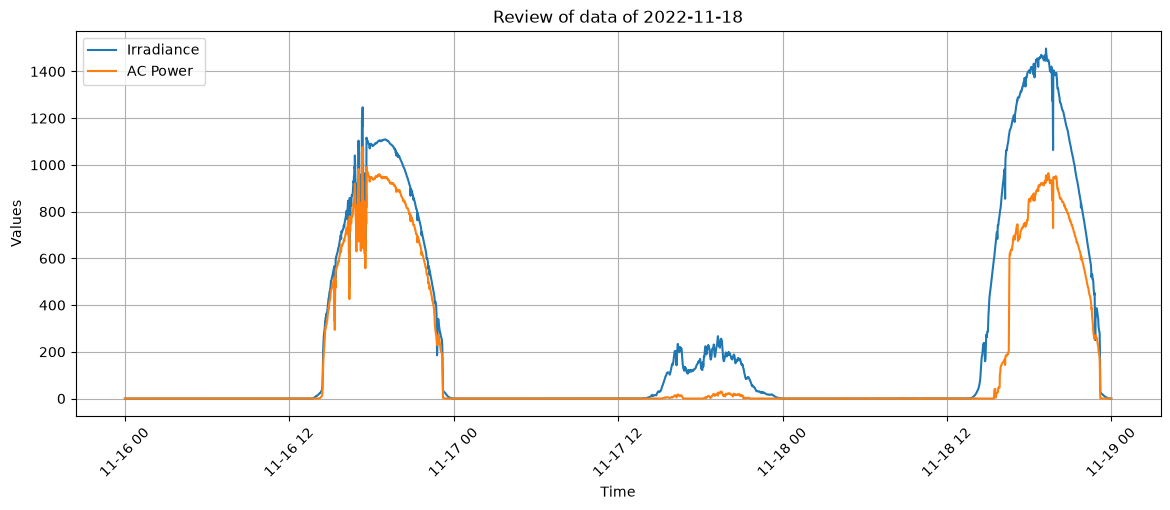

In [19]:
nov_problem_18 = df[
    df['timestamp'].between(
        '2022-11-16',
        '2022-11-19'
    )
]

plt.figure(figsize=(14, 5))
plt.plot(nov_problem_18['timestamp'], nov_problem_18['irradiance'], label='Irradiance')
plt.plot(nov_problem_18['timestamp'], nov_problem_18['ac_power'], label='AC Power')
plt.xlabel('Time')
plt.ylabel('Values')
plt.title('Review of data of 2022-11-18')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

It seems that values from 18 of november of 2022 are excesively low due to a very bad metereological situation, we cannot confirm without checking external data, but the values of ac power following the figure of irradiance give us an idea, so we are going to leave those day in the dataset

now let's find points where there was high irradiance and low ac power grouping by date

In [20]:
low_power_high_irr = df[
    (df["irradiance"] > 500) &
    (df["ac_power"] < 50)
].copy()

low_power_high_irr["date"] = low_power_high_irr["timestamp"].dt.date

daily_anomalies = (
    low_power_high_irr
    .groupby("date")
    .agg(
        anomalous_points=("ac_power", "size"),
        max_irradiance=("irradiance", "max"),
        min_ac_power=("ac_power", "min"),
        mean_ac_power=("ac_power", "mean")
    )
    .sort_values("anomalous_points", ascending=False)
)

daily_anomalies.head(20)

,anomalous_points,max_irradiance,min_ac_power,mean_ac_power
date,,,,
2022-11-25,491,1612.30,0.0000,0.000000
2022-11-26,471,1629.50,0.0000,0.000000
2022-11-27,430,1729.20,0.0000,0.000000
2023-02-23,359,1351.40,0.0000,20.636683
2022-02-23,339,1366.80,0.0000,27.467275
2022-12-22,326,1239.70,2.2667,24.926129
2020-02-05,255,1406.30,0.0000,9.845642
2021-06-11,239,1025.90,0.0000,0.057123
2022-09-23,215,1173.00,0.0000,0.024604


and being more precisely, seeing which is the rate of low power taking into acount the total number of points registered along the day

In [21]:
high_irr = df[df['irradiance'] > 500].copy()
high_irr['date'] = high_irr['timestamp'].dt.date

daily = (
    high_irr
    .groupby('date')
    .agg(
        total_points=('ac_power', 'size'),
        low_power_points=('ac_power', lambda x: (x<50).sum())
    )
)

daily['low_power_pct'] = (
    daily['low_power_points']/daily['total_points']*100
)

daily.sort_values('low_power_pct', ascending=False).head(20)

,total_points,low_power_points,low_power_pct
date,,,
2022-09-22,21,21,100.000000
2020-10-26,211,211,100.000000
2022-11-27,430,430,100.000000
2022-11-26,471,471,100.000000
2022-11-25,491,491,100.000000
2020-04-13,14,14,100.000000
2019-10-10,4,4,100.000000
2022-01-01,100,100,100.000000
2023-02-22,26,26,100.000000


let's group candidates of a shutdown of the station to identify real anomalous values

In [22]:
daily_shutdown_candidates = daily.join(
    daily_anomalies["mean_ac_power"]
) # join is for keeping the columns of mean_ac_power  in the new dataframe

daily_shutdown_candidates = daily_shutdown_candidates[
    (daily_shutdown_candidates["total_points"] >= 200) &
    (daily_shutdown_candidates["low_power_pct"] >= 80) &
    (daily_shutdown_candidates["mean_ac_power"] <= 5)
]

print(daily_shutdown_candidates)

            total_points  low_power_points  low_power_pct  mean_ac_power
date                                                                    
2020-10-26           211               211          100.0       0.503244
2022-11-25           491               491          100.0       0.000000
2022-11-26           471               471          100.0       0.000000
2022-11-27           430               430          100.0       0.000000


In [23]:
df["date"] = df["timestamp"].dt.date

shutdown_dates = daily_shutdown_candidates.index

df["plant_status"] = "normal"

df.loc[
    df["date"].isin(shutdown_dates),
    "plant_status"
] = "shutdown_candidate"

df.loc[
    (~df["date"].isin(shutdown_dates)) &
    (df["irradiance"] > 500) &
    (df["ac_power"] < 50),
    "plant_status"
] = "unexplained_anomaly"


cheking if ambient temp and module temp mean have NaN values and how many of them

In [24]:
df[['ambient_temp', 'module_temp_mean']].isna().sum()

ambient_temp          11
module_temp_mean    5125
dtype: int64

In [25]:
df.loc[
    df['ambient_temp'].isna(),
    ['timestamp', 'ambient_temp']
]

,timestamp,ambient_temp
649117,2020-08-04 10:40:00,NaN
649152,2020-08-04 11:40:00,NaN
650783,2020-08-05 15:41:00,NaN
651832,2020-08-06 11:40:00,NaN
654361,2020-08-08 07:35:00,NaN
655750,2020-08-09 07:40:00,NaN
657198,2020-08-10 09:40:00,NaN
658849,2020-08-11 13:36:00,NaN
675384,2020-08-23 07:35:00,NaN
678654,2020-08-25 15:36:00,NaN


there are only a few missing values on ambient temp column

In [26]:
df["ambient_temp"] = df["ambient_temp"].interpolate()

In [27]:
df["ambient_temp"].isna().sum()

np.int64(0)

In [28]:
df.loc[
    df["module_temp_mean"].isna(),
    ["timestamp", "module_temp_mean"]
].head(20)

,timestamp,module_temp_mean
649117,2020-08-04 10:40:00,NaN
649152,2020-08-04 11:40:00,NaN
650783,2020-08-05 15:41:00,NaN
651612,2020-08-06 07:40:00,NaN
651832,2020-08-06 11:40:00,NaN
654361,2020-08-08 07:35:00,NaN
655750,2020-08-09 07:40:00,NaN
657103,2020-08-10 07:40:00,NaN
657198,2020-08-10 09:40:00,NaN
658849,2020-08-11 13:36:00,NaN


let's see how many missing values are grouped in module temp mean to see if is temporary or it lasted a big period of time

In [29]:
is_nan = df["module_temp_mean"].isna()

groups = is_nan.ne(is_nan.shift()).cumsum()

nan_blocks = (
    is_nan[is_nan]
    .groupby(groups)
    .size()
    .sort_values(ascending=False)
)

print(nan_blocks.head(20))

module_temp_mean
96     1455
104    1183
98     1146
100     469
106     281
30      175
92      130
34      104
102      79
94       31
90       10
74        5
38        5
70        4
86        3
28        3
68        2
56        2
44        2
72        2
Name: module_temp_mean, dtype: int64


is better if we can see the actual period of missing values

In [30]:
is_nan = df["module_temp_mean"].isna()

groups = is_nan.ne(is_nan.shift()).cumsum()

nan_blocks = (
    df[is_nan]
    .assign(group=groups[is_nan])
    .groupby("group")
    .agg(
        start=("timestamp", "min"),
        end=("timestamp", "max"),
        n_missing=("timestamp", "size")
    )
)

nan_blocks["duration"] = (
    nan_blocks["end"] - nan_blocks["start"]
)

nan_blocks.sort_values(
    "n_missing",
    ascending=False
).head(20)


,start,end,n_missing,duration
group,,,,
96,2022-11-25 10:59:00,2022-11-26 11:13:00,1455,1 days 00:14:00
104,2022-11-27 15:36:00,2022-11-28 11:18:00,1183,0 days 19:42:00
98,2022-11-26 11:16:00,2022-11-27 06:21:00,1146,0 days 19:05:00
100,2022-11-27 06:24:00,2022-11-27 14:12:00,469,0 days 07:48:00
106,2022-11-28 11:20:00,2022-11-28 16:00:00,281,0 days 04:40:00
30,2022-11-24 21:40:00,2022-11-25 00:34:00,175,0 days 02:54:00
92,2022-11-25 08:12:00,2022-11-25 10:21:00,130,0 days 02:09:00
34,2022-11-25 00:47:00,2022-11-25 02:30:00,104,0 days 01:43:00
102,2022-11-27 14:14:00,2022-11-27 15:32:00,79,0 days 01:18:00


now we apply interpolate function for groups with less than 5 missing values in a row

In [31]:
small_nan_groups = nan_blocks[
    nan_blocks["n_missing"] <= 5
].index

interpolated = df["module_temp_mean"].interpolate()

mask = is_nan & groups.isin(small_nan_groups)

df.loc[mask, "module_temp_mean"] = interpolated[mask]

and for the big groups that are grouped in a few days (between 24 and 28 of november, near the period that gave us problems at the beginning), so is better to eliminate them, because this missing data can confuse the model in training

In [32]:
df = df.dropna(subset=["module_temp_mean"])

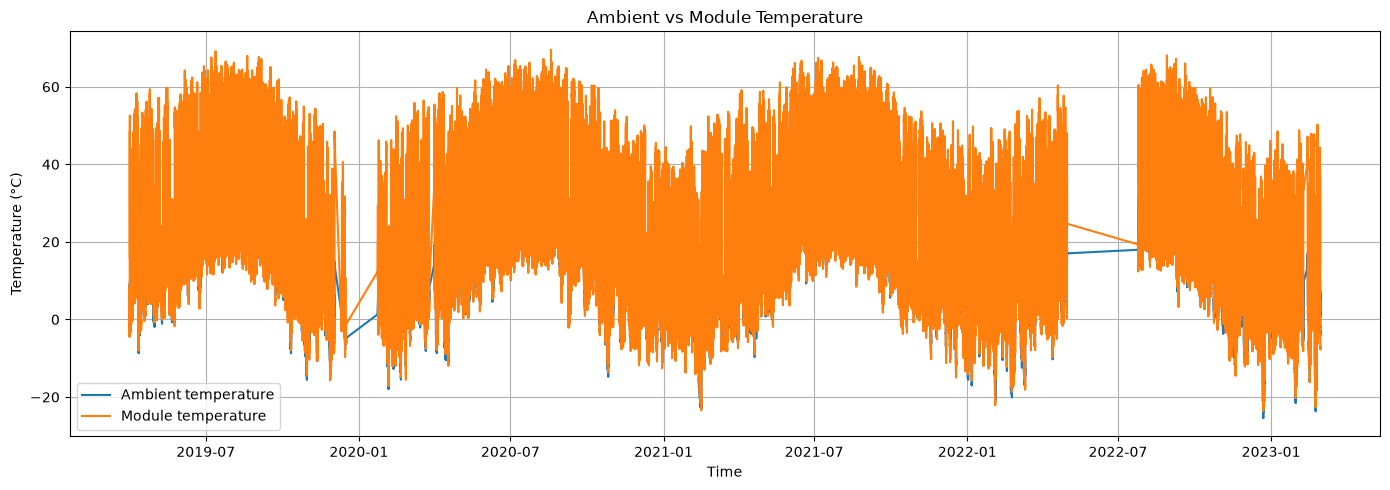

In [33]:
plt.figure(figsize=(14, 5))

plt.plot(df["timestamp"], df["ambient_temp"], label="Ambient temperature")
plt.plot(df["timestamp"], df["module_temp_mean"], label="Module temperature")

plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.title("Ambient vs Module Temperature")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [34]:
daily_temp = (
    df.set_index("timestamp")
      [["ambient_temp", "module_temp_mean"]]
      .resample("D")
      .mean()
)

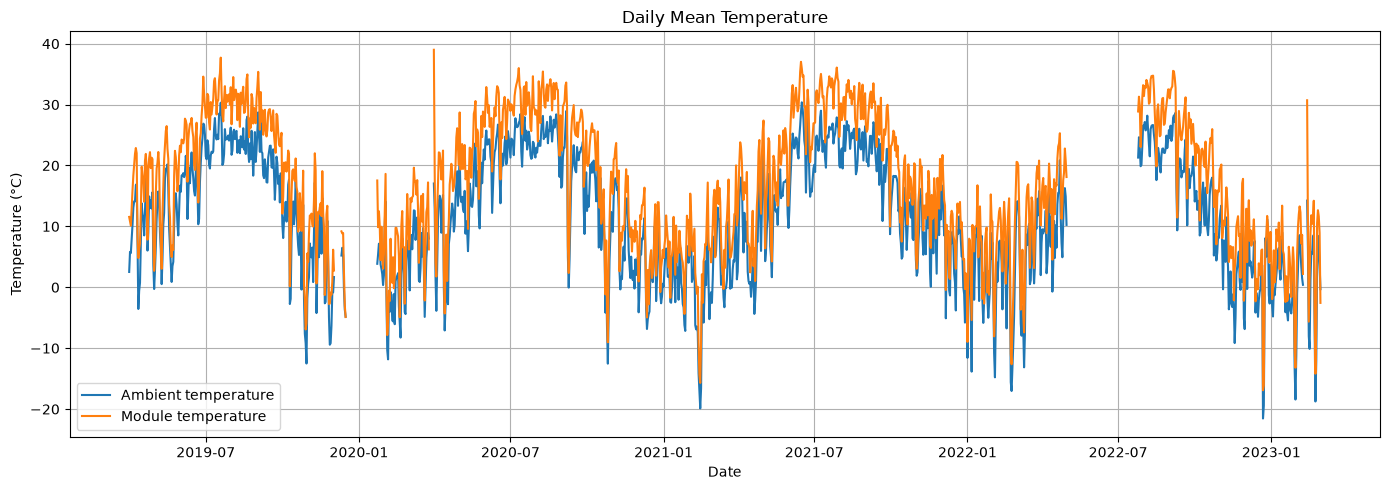

In [35]:
plt.figure(figsize=(14, 5))

plt.plot(
    daily_temp.index,
    daily_temp["ambient_temp"],
    label="Ambient temperature"
)

plt.plot(
    daily_temp.index,
    daily_temp["module_temp_mean"],
    label="Module temperature"
)

plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.title("Daily Mean Temperature")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

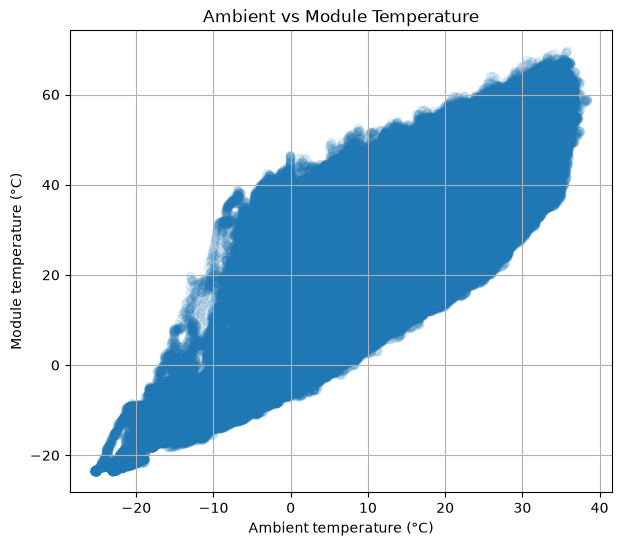

In [36]:
plt.figure(figsize=(7, 6))

plt.scatter(
    df["ambient_temp"],
    df["module_temp_mean"],
    alpha=0.1
)

plt.xlabel("Ambient temperature (°C)")
plt.ylabel("Module temperature (°C)")
plt.title("Ambient vs Module Temperature")
plt.grid(True)
plt.show()

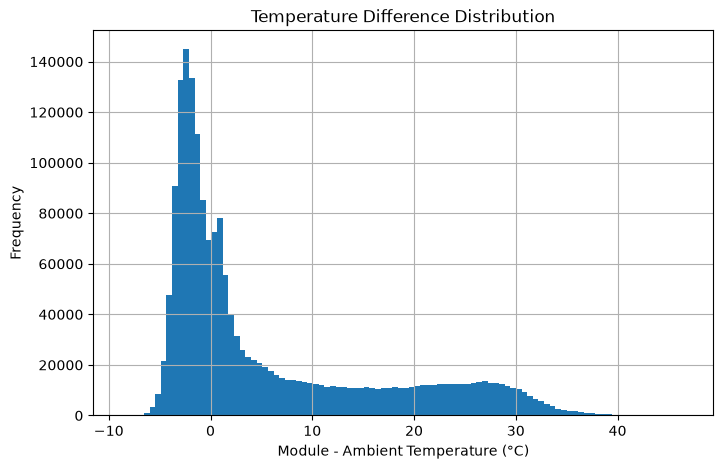

In [37]:
df["temp_difference"] = (
    df["module_temp_mean"] - df["ambient_temp"]
)

df["temp_difference"].describe()

plt.figure(figsize=(8, 5))

plt.hist(df["temp_difference"], bins=100)

plt.xlabel("Module - Ambient Temperature (°C)")
plt.ylabel("Frequency")
plt.title("Temperature Difference Distribution")
plt.grid(True)
plt.show()

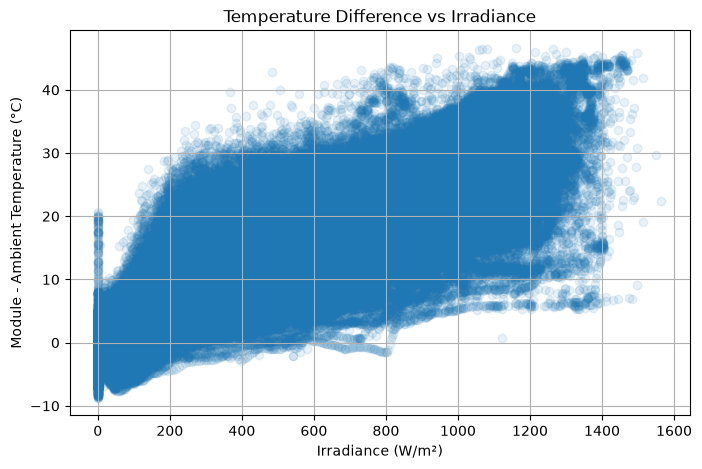

In [38]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["irradiance"],
    df["temp_difference"],
    alpha=0.1
)

plt.xlabel("Irradiance (W/m²)")
plt.ylabel("Module - Ambient Temperature (°C)")
plt.title("Temperature Difference vs Irradiance")
plt.grid(True)
plt.show()

is strange for irradiance = 0, there is some points of temperature diference between 10 and 20 degrees, let's investigate them

In [39]:
df[
    (df["irradiance"] == 0) &
    (df["temp_difference"] > 15)
][[
    "timestamp",
    "irradiance",
    "ambient_temp",
    "module_temp_mean",
    "temp_difference"
]].head(20)

,timestamp,irradiance,ambient_temp,module_temp_mean,temp_difference
1196667,2021-08-20 15:49:00,0.0,18.163,35.636667,17.473667
1683368,2022-07-25 15:30:00,0.0,23.382,38.631667,15.249667
1683369,2022-07-25 15:31:00,0.0,23.389,38.925667,15.536667
1683370,2022-07-25 15:32:00,0.0,23.522,39.008667,15.486667
1683371,2022-07-25 15:33:00,0.0,23.615,39.171667,15.556667
1683372,2022-07-25 15:34:00,0.0,23.777,39.168667,15.391667
1683373,2022-07-25 15:35:00,0.0,23.834,39.411333,15.577333
1683374,2022-07-25 15:36:00,0.0,23.821,39.581333,15.760333
1683375,2022-07-25 15:37:00,0.0,23.765,39.758000,15.993000
1683376,2022-07-25 15:38:00,0.0,23.841,39.877000,16.036000


In [40]:
df[
    df["timestamp"].between(
        "2022-07-25 15:30:00",
        "2022-07-25 16:00:00"
    )
][[
    "timestamp",
    "irradiance",
    "dc_power",
    "ac_power",
    "ambient_temp",
    "module_temp_mean"
]]

,timestamp,irradiance,dc_power,ac_power,ambient_temp,module_temp_mean
1683368,2022-07-25 15:30:00,0.0,490.65,399.28,23.382,38.631667
1683369,2022-07-25 15:31:00,0.0,492.51,400.03,23.389,38.925667
1683370,2022-07-25 15:32:00,0.0,493.47,399.96,23.522,39.008667
1683371,2022-07-25 15:33:00,0.0,501.22,410.41,23.615,39.171667
1683372,2022-07-25 15:34:00,0.0,509.74,415.91,23.777,39.168667
1683373,2022-07-25 15:35:00,0.0,509.00,419.38,23.834,39.411333
1683374,2022-07-25 15:36:00,0.0,516.40,421.09,23.821,39.581333
1683375,2022-07-25 15:37:00,0.0,516.01,423.91,23.765,39.758000
1683376,2022-07-25 15:38:00,0.0,522.47,426.94,23.841,39.877000
1683377,2022-07-25 15:39:00,0.0,521.19,428.46,23.922,40.402333


counting how many cases of 0 irradiance and a relevant ac power generation

In [41]:
irradiance_fault = df[
    (df["irradiance"] == 0) &
    (df["ac_power"] > 50)
]

print(len(irradiance_fault))
print(irradiance_fault["timestamp"].min())
print(irradiance_fault["timestamp"].max())

156
2021-08-20 15:49:00
2023-02-19 22:38:00


grouping these cases

In [42]:
irradiance_fault = (
    (df["irradiance"] == 0) &
    (df["ac_power"] > 50)
)

groups = irradiance_fault.ne(irradiance_fault.shift()).cumsum()

fault_blocks = (
    df[irradiance_fault]
    .assign(group=groups[irradiance_fault])
    .groupby("group")
    .agg(
        start=("timestamp", "min"),
        end=("timestamp", "max"),
        n_points=("timestamp", "size")
    )
)

fault_blocks["duration"] = (
    fault_blocks["end"] - fault_blocks["start"]
)

fault_blocks.sort_values(
    "n_points",
    ascending=False
)

,start,end,n_points,duration
group,,,,
6,2022-07-25 13:39:00,2022-07-25 14:42:00,64,0 days 01:03:00
10,2022-07-25 15:23:00,2022-07-25 16:14:00,52,0 days 00:51:00
8,2022-07-25 14:45:00,2022-07-25 15:21:00,37,0 days 00:36:00
2,2021-08-20 15:49:00,2021-08-20 15:49:00,1,0 days 00:00:00
4,2022-02-10 19:03:00,2022-02-10 19:03:00,1,0 days 00:00:00
12,2023-02-19 22:38:00,2023-02-19 22:38:00,1,0 days 00:00:00


let's drop the rows that have the conditions of 0 irradiance and generation of ac power

In [43]:
irradiance_sensor_fault = (
    (df["irradiance"] == 0) &
    (df["ac_power"] > 50)
)

df = df[~irradiance_sensor_fault] 

In [44]:
print(
    ((df["irradiance"] == 0) & (df["ac_power"] > 50)).sum()
)

0


let's check that the cleaning phase is over and correctly finished

In [45]:
df.info()
df.isnull().sum()
df.describe()

<class 'pandas.DataFrame'>
Index: 1842869 entries, 20411 to 1990899
Data columns (total 9 columns):
 #   Column            Dtype         
---  ------            -----         
 0   timestamp         datetime64[us]
 1   irradiance        float64       
 2   dc_power          float64       
 3   ac_power          float64       
 4   ambient_temp      float64       
 5   module_temp_mean  float64       
 6   date              object        
 7   plant_status      str           
 8   temp_difference   float64       
dtypes: datetime64[us](1), float64(6), object(1), str(1)
memory usage: 151.4+ MB


,timestamp,irradiance,dc_power,ac_power,ambient_temp,module_temp_mean,temp_difference
count,1842869,1.842855e+06,1.842863e+06,1.842861e+06,1.842869e+06,1.842869e+06,1.842869e+06
mean,2021-02-27 08:09:05.082618,2.371106e+02,2.251078e+02,1.830178e+02,1.149057e+01,1.717974e+01,5.689168e+00
min,2019-03-31 00:01:00,0.000000e+00,0.000000e+00,0.000000e+00,-2.543800e+01,-2.359667e+01,-8.760600e+00
25%,2020-04-06 17:28:00,0.000000e+00,0.000000e+00,0.000000e+00,3.089400e+00,3.255100e+00,-2.077667e+00
50%,2021-02-24 14:37:00,2.653400e+00,4.368000e-02,0.000000e+00,1.169900e+01,1.466500e+01,6.412000e-01
75%,2022-01-11 15:25:00,3.868850e+02,3.615000e+02,2.940400e+02,2.014500e+01,2.872900e+01,1.128077e+01
max,2023-03-01 06:59:00,1.564900e+03,1.638500e+03,1.339500e+03,3.843000e+01,6.954200e+01,4.662576e+01
std,NaN,3.584736e+02,3.530372e+02,2.894335e+02,1.107028e+01,1.764365e+01,1.072284e+01


looking for the correlations between features

In [46]:
corr = df.select_dtypes(include="number").corr()
print(corr)

                  irradiance  dc_power  ac_power  ambient_temp  \
irradiance          1.000000  0.983179  0.983115      0.307301   
dc_power            0.983179  1.000000  0.999747      0.315199   
ac_power            0.983115  0.999747  1.000000      0.308799   
ambient_temp        0.307301  0.315199  0.308799      1.000000   
module_temp_mean    0.774790  0.775774  0.771228      0.816276   
temp_difference     0.957603  0.951072  0.950199      0.310721   

                  module_temp_mean  temp_difference  
irradiance                0.774790         0.957603  
dc_power                  0.775774         0.951072  
ac_power                  0.771228         0.950199  
ambient_temp              0.816276         0.310721  
module_temp_mean          1.000000         0.802703  
temp_difference           0.802703         1.000000  


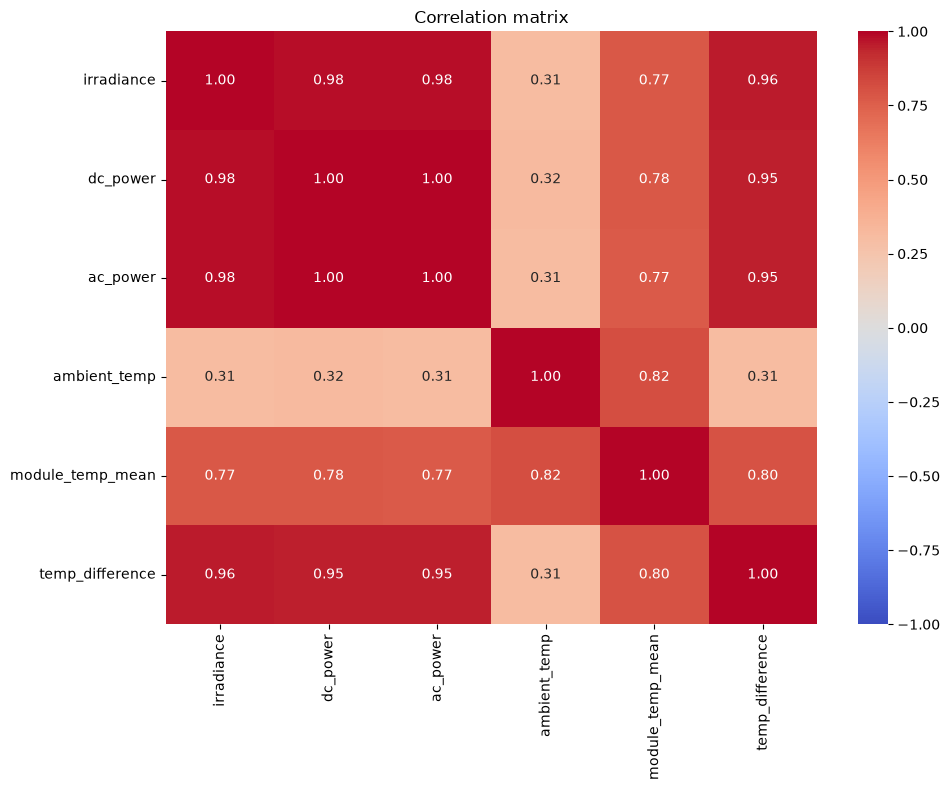

In [47]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1
)

plt.title('Correlation matrix')
plt.tight_layout()
plt.show()

let's analize the features after the cleaning process with a boxplot

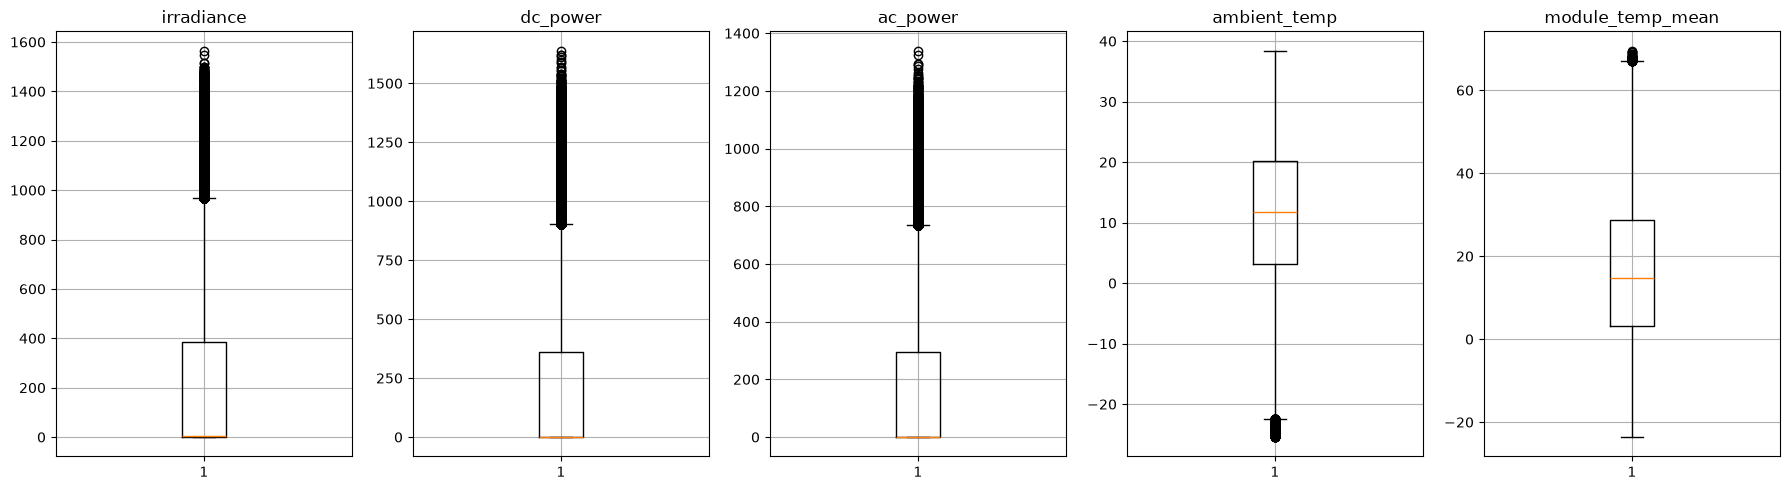

In [48]:
variables = [
    'irradiance',
    'dc_power',
    'ac_power',
    'ambient_temp',
    'module_temp_mean'
]

fig, axes = plt.subplots(1, 5, figsize=(18,5))

for ax, variable in zip(axes, variables):
    ax.boxplot(df[variable].dropna())
    ax.set_title(variable)
    ax.grid(True)

plt.tight_layout()
plt.show()

improving the visualization ploting only data during day, droping zeros of night records

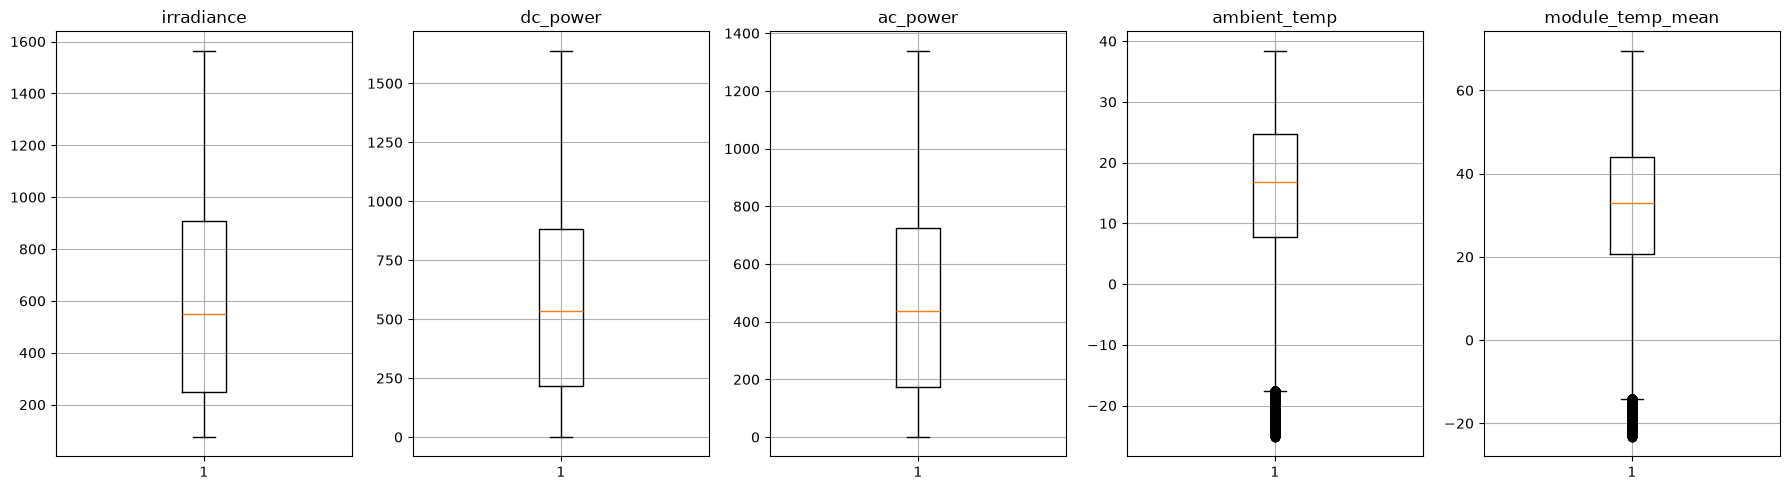

In [49]:
df_day = df[df['irradiance'] > 75]

fig1, axes_day = plt.subplots(1, 5, figsize=(18,5))

for ax, variable in zip(axes_day, variables):
    ax.boxplot(df_day[variable].dropna())
    ax.set_title(variable)
    ax.grid(True)

plt.tight_layout()
plt.show()

it seems to be better than the beginning, now let's check the frequency distribution of some variables

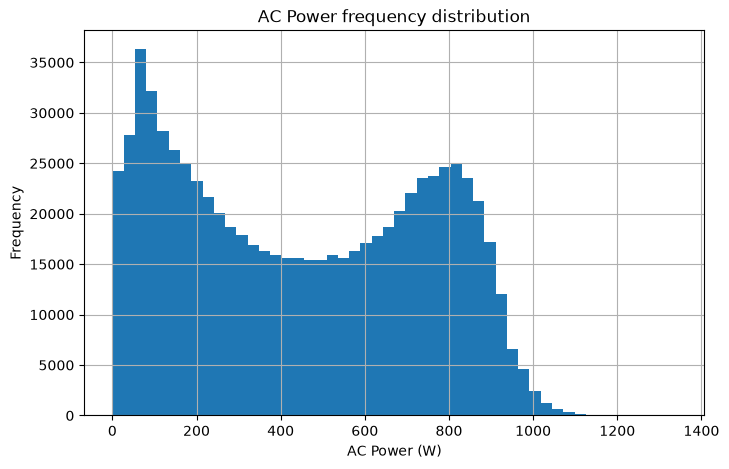

In [50]:
plt.figure(figsize=(8,5))

plt.hist(df_day['ac_power'], bins=50)

plt.xlabel('AC Power (W)')
plt.ylabel('Frequency')
plt.title('AC Power frequency distribution')
plt.grid(True)
plt.show()

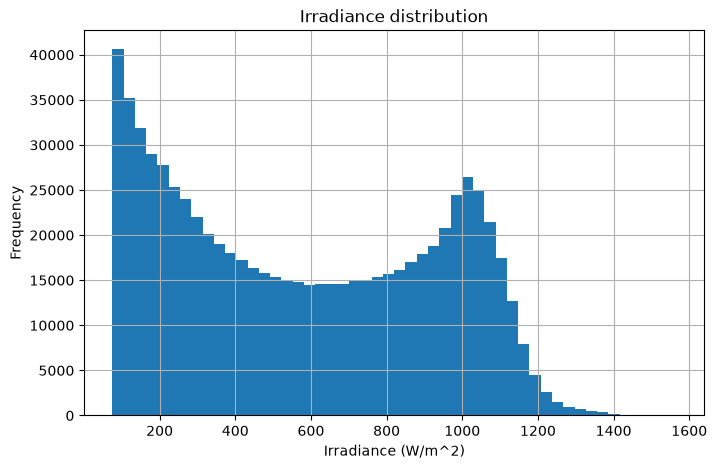

In [51]:
plt.figure(figsize=(8,5))

plt.hist(df_day['irradiance'], bins=50)

plt.xlabel('Irradiance (W/m^2)')
plt.ylabel('Frequency')
plt.title('Irradiance distribution')
plt.grid(True)
plt.show()

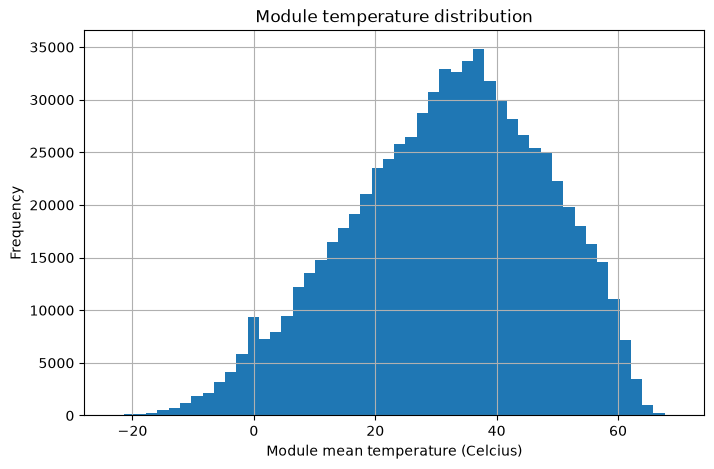

In [52]:
plt.figure(figsize=(8,5))

plt.hist(df_day['module_temp_mean'], bins=50)

plt.xlabel('Module mean temperature (Celcius)')
plt.ylabel('Frequency')
plt.title('Module temperature distribution')
plt.grid(True)
plt.show()

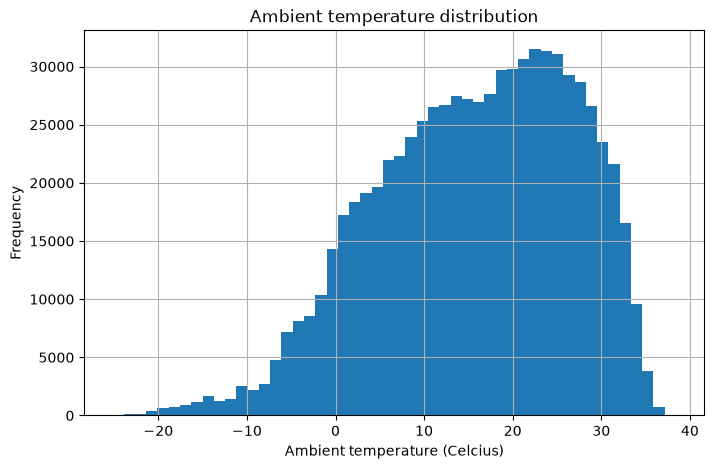

In [53]:
plt.figure(figsize=(8,5))

plt.hist(df_day['ambient_temp'], bins=50)

plt.xlabel('Ambient temperature (Celcius)')
plt.ylabel('Frequency')
plt.title('Ambient temperature distribution')
plt.grid(True)
plt.show()

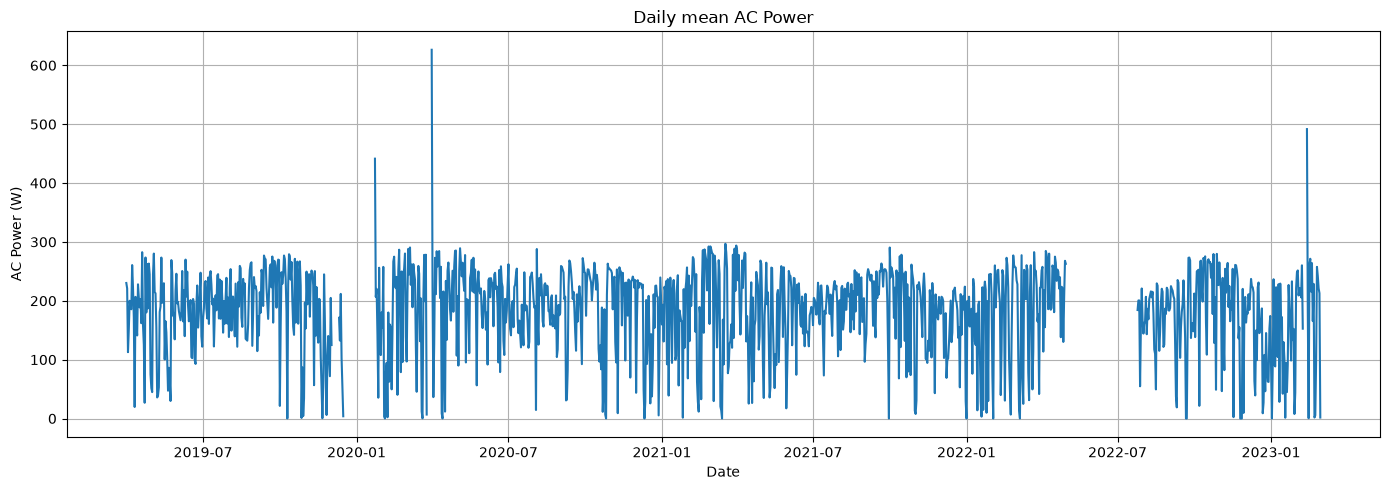

In [54]:
daily_mean = (
    df.set_index('timestamp')
    [['irradiance', 'ac_power', 'ambient_temp', 'module_temp_mean']]
    .resample('D')
    .mean()
)

plt.figure(figsize=(14,5))

plt.plot(
    daily_mean.index,
    daily_mean['ac_power']
)

plt.xlabel('Date')
plt.ylabel('AC Power (W)')
plt.title('Daily mean AC Power')
plt.grid(True)
plt.tight_layout()
plt.show()

there are 3 days with anormal values, we must study them

In [55]:
daily_mean.sort_values("ac_power", ascending=False)[["ac_power"]].head()

,ac_power
timestamp,
2020-03-31,626.412291
2023-02-13,491.634660
2020-01-23,441.407144
2021-03-18,296.853267
2021-03-31,293.809941


we already loc the 3 days with anormal values, let's check what happened the day before and after

In [56]:
daily_mean.loc[
    ["2020-01-23", "2020-03-31", "2023-02-13"],
    ["irradiance", "ac_power"]
]

for date in ["2020-01-23", "2020-03-31", "2023-02-13"]:
    print(daily_mean.loc[
        pd.date_range(date, periods=1)[0] - pd.Timedelta(days=1):
        pd.date_range(date, periods=1)[0] + pd.Timedelta(days=1),
        ["irradiance", "ac_power"]
    ])
    print()

            irradiance    ac_power
timestamp                         
2020-01-22         NaN         NaN
2020-01-23  497.599701  441.407144
2020-01-24  238.750234  206.728538

            irradiance    ac_power
timestamp                         
2020-03-30         NaN         NaN
2020-03-31  769.752438  626.412291
2020-04-01  272.872467  221.209322

            irradiance    ac_power
timestamp                         
2023-02-12         NaN         NaN
2023-02-13  610.057417  491.634660
2023-02-14  221.107697  184.012023



the NaN values give us an idea, values of these 3 days are NaN and probably the days next to them have low number of records (compared to normal day that has 1440)

In [57]:
daily_count = (
    df.set_index("timestamp")["ac_power"]
      .resample("D")
      .count()
)

print(
    daily_count.loc[
        ["2020-01-22", "2020-01-23", "2020-01-24",
         "2020-03-30", "2020-03-31", "2020-04-01",
         "2023-02-12", "2023-02-13", "2023-02-14"]
    ]
)

timestamp
2020-01-22       0
2020-01-23     340
2020-01-24    1440
2020-03-30       0
2020-03-31     436
2020-04-01    1440
2023-02-12       0
2023-02-13     398
2023-02-14    1440
Name: ac_power, dtype: int64


once is confirmed, we can delete these days to improve the plot of daily ac power mean

In [58]:
incomplete_days = [
    "2020-01-23",
    "2020-03-31",
    "2023-02-13"
]

df = df[
    ~df["timestamp"].dt.strftime("%Y-%m-%d").isin(incomplete_days)
]

trying again

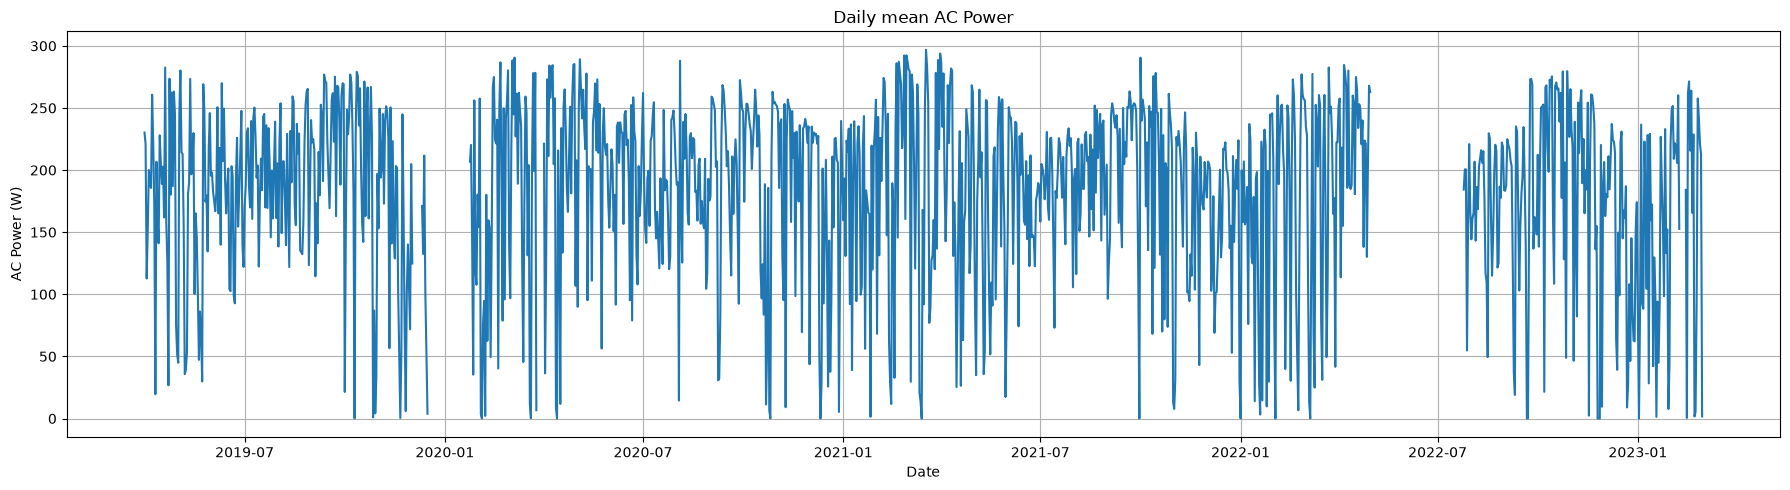

In [59]:
daily_mean = (
    df.set_index('timestamp')
    [['irradiance', 'ac_power', 'ambient_temp', 'module_temp_mean']]
    .resample('D')
    .mean()
)

plt.figure(figsize=(18,5))

plt.plot(
    daily_mean.index,
    daily_mean['ac_power']
)

plt.xlabel('Date')
plt.ylabel('AC Power (W)')
plt.title('Daily mean AC Power')
plt.grid(True)
plt.tight_layout()
plt.show()

checking if the data cleaning process is finished

In [60]:
features_check = [
    "irradiance",
    "ambient_temp",
    "module_temp_mean"
]

print(df[features_check].isna().sum())
print("AC power:", df["ac_power"].isna().sum())

irradiance          14
ambient_temp         0
module_temp_mean     0
dtype: int64
AC power: 8


there are some NaN values left, to fix it

In [61]:
df.loc[
    df['irradiance'].isna(),
    ['timestamp', 'irradiance']
]

,timestamp,irradiance
909253,2021-02-01 23:25:00,NaN
909254,2021-02-01 23:26:00,NaN
909256,2021-02-01 23:28:00,NaN
909259,2021-02-01 23:31:00,NaN
909260,2021-02-01 23:32:00,NaN
1554017,2022-04-26 19:39:00,NaN
1554019,2022-04-26 19:41:00,NaN
1682844,2022-07-25 06:46:00,NaN
1683196,2022-07-25 12:38:00,NaN
1683197,2022-07-25 12:39:00,NaN


In [62]:
df['irradiance'] = df['irradiance'].interpolate()

and for ac power variable

In [63]:
df.loc[
    df['ac_power'].isna(),
    ['timestamp', 'ac_power']
]

,timestamp,ac_power
650783,2020-08-05 15:41:00,NaN
651832,2020-08-06 11:40:00,NaN
657198,2020-08-10 09:40:00,NaN
678654,2020-08-25 15:36:00,NaN
1859371,2022-11-24 20:53:00,NaN
1859377,2022-11-24 20:59:00,NaN
1859385,2022-11-24 21:07:00,NaN
1954766,2023-01-30 06:25:00,NaN


In [64]:
df.dropna(subset=['ac_power'], inplace=True)

see if time is always increasing and there is no duplicated values

In [65]:
print("Ordenado:", df["timestamp"].is_monotonic_increasing)
print("Duplicados:", df["timestamp"].duplicated().sum())

Ordenado: True
Duplicados: 0


In [66]:
time_diff = df["timestamp"].diff()

print(time_diff.value_counts().head(10))

timestamp
0 days 00:01:00    1841574
0 days 01:00:00         40
0 days 00:31:00         13
0 days 00:26:00         10
0 days 00:32:00         10
0 days 00:02:00          7
0 days 00:27:00          4
0 days 00:11:00          2
0 days 02:11:00          2
8 days 11:41:00          1
Name: count, dtype: int64


In [67]:
print(df.isna().sum())

timestamp           0
irradiance          0
dc_power            2
ac_power            0
ambient_temp        0
module_temp_mean    0
date                0
plant_status        0
temp_difference     0
dtype: int64


In [68]:
df.dropna(subset=['dc_power'], inplace=True)

but the variables that are important and that we will use as features are only:
- irradiance
- ambient temperature
- module mean temperature

In [69]:
df['plant_status'].value_counts()

plant_status
normal                 1835920
unexplained_anomaly       3969
shutdown_candidate        1796
Name: count, dtype: int64

if plant_status will not be a real feature, we will use the study of the plant situation to weight the data in training sessions, this is because 3969 values are anomalies that we can't explain, so probably they are data with less quality than the rest of the dataset, values that we classify as shutdowns candidates will be weighted as normal, because in real world it can really happen

also, we need to improve time as variables, timestamp can't extract info from time as we can, so let's create two new features: Hour, to give more info of how irradiance and generation of ac power change during the day, and day of the year, to give info of how temperatures and irradiance change during a hole year

both are cyclic, so we can change values to give the model a feature that can difference between 23:00 and 00:00 without thinking they are way to far between them, or between day 360 (end of the year) and day 4 (the beginning of the year), both are close and share information about temperature and irradiance along time

In [70]:
df['hour'] = df['timestamp'].dt.hour

df['day_of_year'] = df['timestamp'].dt.dayofyear

df.head(2)

,timestamp,irradiance,dc_power,ac_power,ambient_temp,module_temp_mean,date,plant_status,temp_difference,hour,day_of_year
20411,2019-03-31 00:01:00,56.507,34.868,23.639,2.4424,8.090500,2019-03-31,normal,5.648100,0,90
20412,2019-03-31 00:02:00,54.712,32.398,22.420,2.3776,8.018467,2019-03-31,normal,5.640867,0,90


changing time variables into cyclic features

In [71]:
df = add_time_features(df)
df[["hour_sin", "hour_cos", "day_of_year_sin", "day_of_year_cos"]].head()

,hour_sin,hour_cos,day_of_year_sin,day_of_year_cos
20411,0.0,1.0,0.999769,0.021516
20412,0.0,1.0,0.999769,0.021516
20413,0.0,1.0,0.999769,0.021516
20414,0.0,1.0,0.999769,0.021516
20415,0.0,1.0,0.999769,0.021516


we already have a complete and clean dataset, so we are going to save in a parquet dataset to continue creating the model in another clean notebook

In [72]:
df.to_parquet("../data/processed/solar_clean.parquet")